# Wine Quality Classification — K-Nearest Neighbors (KNN)

**Goal:** Predict a wine's **quality score** (3–9) from its physicochemical properties — acidity, sugar, chlorides, sulfur dioxide, density, pH, sulphates, and alcohol — using a KNN classifier.

**Dataset:** `wine_data.csv` — 21,000 wine samples, 12 columns (11 numeric features + `quality` target).

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 2. Load & Clean Data

In [2]:
df = pd.read_csv("wine_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (21000, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3


In [3]:
print("Quality classes:", sorted(df['quality'].unique()))
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Quality classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Missing values:
 fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows: 6060


In [4]:
# Remove duplicate records
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

df.info()

Shape after removing duplicates: (14940, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 14940 entries, 0 to 20994
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         14940 non-null  float64
 1   volatile_acidity      14940 non-null  float64
 2   citric_acid           14940 non-null  float64
 3   residual_sugar        14940 non-null  float64
 4   chlorides             14940 non-null  float64
 5   free_sulfur_dioxide   14940 non-null  float64
 6   total_sulfur_dioxide  14940 non-null  float64
 7   density               14940 non-null  float64
 8   pH                    14940 non-null  float64
 9   sulphates             14940 non-null  float64
 10  alcohol               14940 non-null  float64
 11  quality               14940 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 1.5 MB


**Insight:** No missing values, but a large number of **duplicate rows (6,060)** were found and removed (21,000 → 14,940). `quality` is an **ordinal, multi-class target with 7 classes (3–9)**, which is a harder classification problem than binary tasks.

In [5]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,14940.000000,14940.000000,14940.000000,14940.000000,14940.000000,14940.000000,14940.000000,14940.000000,14940.000000,14940.000000,14940.000000,14940.000000
mean,9.619956,0.746201,0.762662,29.421767,0.190994,122.365000,220.594525,1.008847,3.164686,0.988583,11.260888,5.973695
std,2.440643,0.369823,0.392536,19.674421,0.126539,78.780757,102.328384,0.012278,0.171607,0.414441,1.184349,1.908031
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,7.300000,0.370000,0.370000,6.500000,0.059000,38.000000,137.000000,0.996300,3.040000,0.580000,10.400000,4.000000
50%,9.700000,0.785000,0.820000,36.000000,0.192000,136.550000,228.000000,1.010970,3.150000,1.020000,11.300000,6.000000
75%,11.600000,1.060000,1.100000,46.200000,0.290000,190.900000,307.000000,1.019230,3.280000,1.340000,12.200000,8.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


## 3. Exploratory Data Analysis

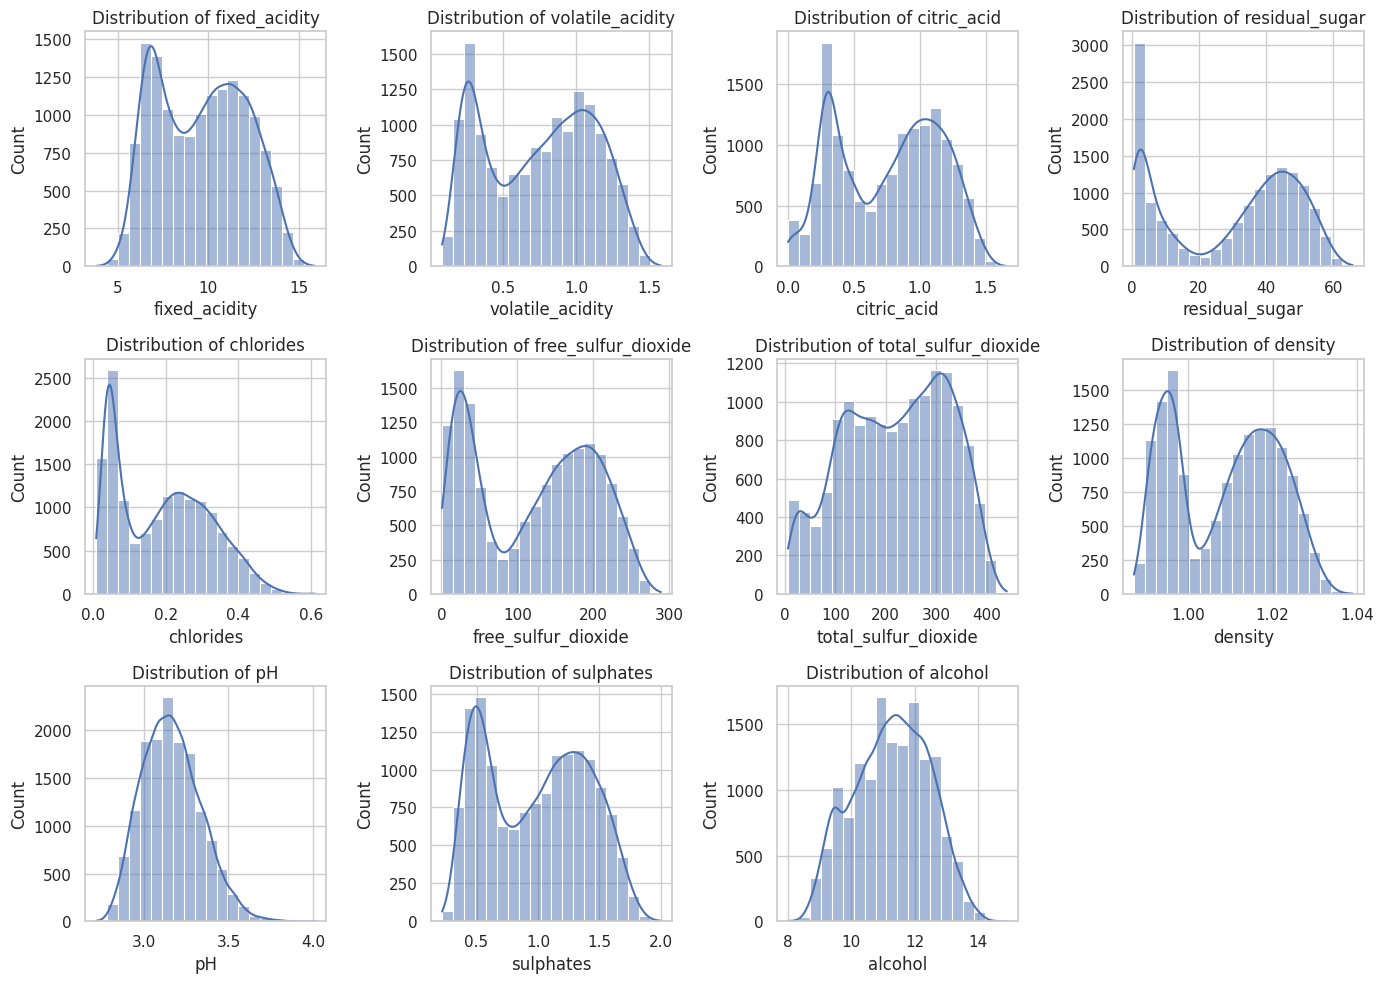

In [6]:
# Distribution of numeric features
feature_cols = df.drop(columns=["quality"]).columns

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, kde=True, bins=20, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

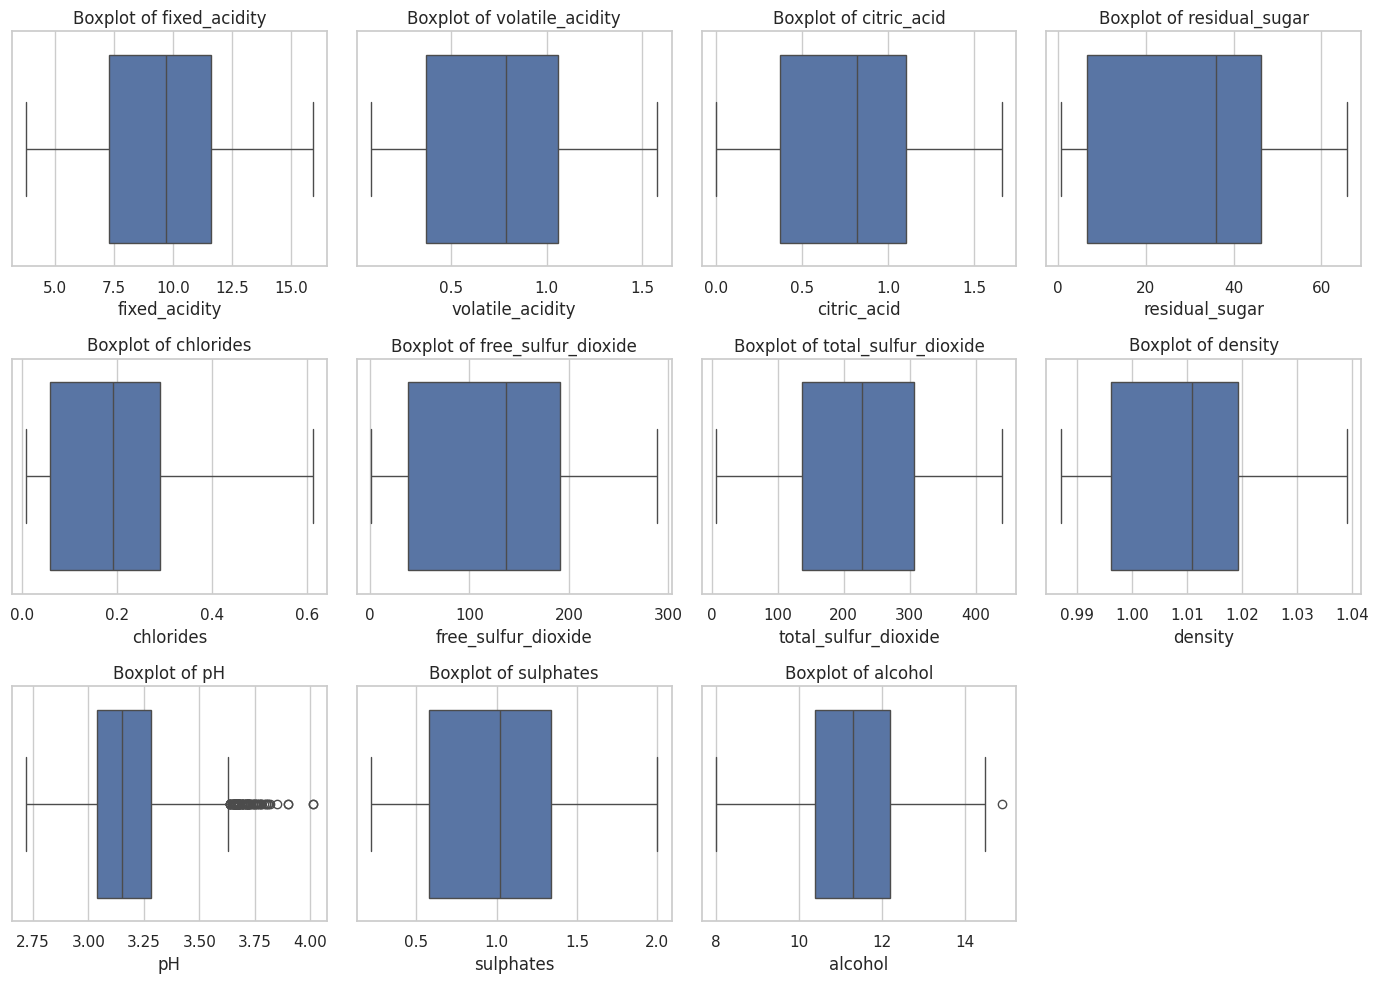

In [7]:
# Boxplots to check for outliers
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

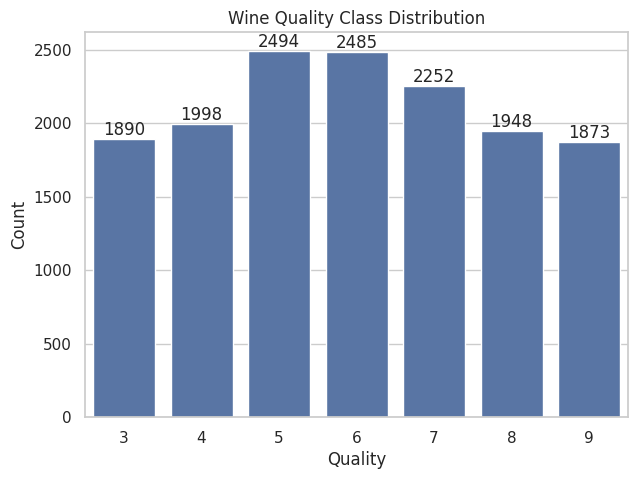

In [8]:
# Class distribution of the target
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="quality", data=df, order=sorted(df["quality"].unique()))
ax.bar_label(ax.containers[0])
plt.xlabel("Quality")
plt.ylabel("Count")
plt.title("Wine Quality Class Distribution")
plt.show()

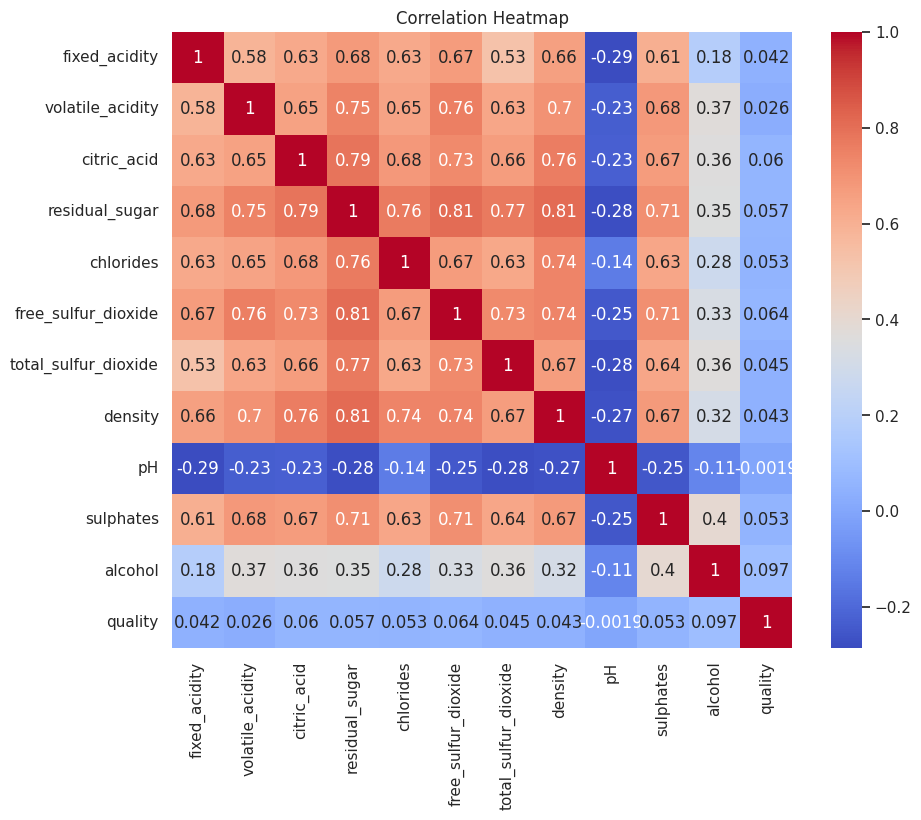

In [9]:
# Correlation between features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Insight:** Quality classes are **heavily imbalanced** — most wines fall in the mid-range (5–6), with very few at the extremes (3, 9). Several features (e.g. `free_sulfur_dioxide` vs `total_sulfur_dioxide`, `density` vs `alcohol`) show visible correlation, and outliers are present in most features, which can affect a distance-based model like KNN.

## 4. Preprocessing

Split the data, then scale all numeric features — KNN is distance-based, so unscaled features (e.g. `total_sulfur_dioxide` in the hundreds vs `chlorides` near zero) would dominate the distance calculation.

In [10]:
X = df.drop(columns=["quality"])
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (11952, 11)
Test shape: (2988, 11)


## 5. Train the KNN Model

In [11]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

train_score = knn_model.score(X_train_scaled, y_train)
test_score = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy:  {test_score:.4f}")

Train Accuracy: 0.5275
Test Accuracy:  0.2955


## 6. Model Evaluation

In [12]:
def evaluate_model(y_test, y_pred):
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    }
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return metrics


evaluate_model(y_test, y_pred)

Accuracy: 0.2955
Precision: 0.2967
Recall: 0.2955
F1 Score: 0.2925

Confusion Matrix:
 [[111  79  21   3  42  70  51]
 [127  81  38  15  45  60  51]
 [ 34  37 226 114  25  32  20]
 [ 10   8 131 265  54   6   3]
 [107  61  26 107  90  52  45]
 [115  76  16  16  43  57  53]
 [117  77  15   1  40  62  53]]


{'Accuracy': 0.2955153949129853,
 'Precision': 0.2967390093697935,
 'Recall': 0.2955153949129853,
 'F1 Score': 0.2925153456310616}

**Insight:** At `k=5`, train accuracy (0.53) is already low and test accuracy (0.30) is much lower — the model **underfits badly** on this 7-class problem. Precision/recall/F1 (~0.30) confirm the model struggles most on the minority quality classes (3, 4, 8, 9), which the confusion matrix shows are frequently misclassified into the majority classes (5, 6).

## 7. Tuning K (Number of Neighbors)

Best k: 18, Best test accuracy: 0.3166


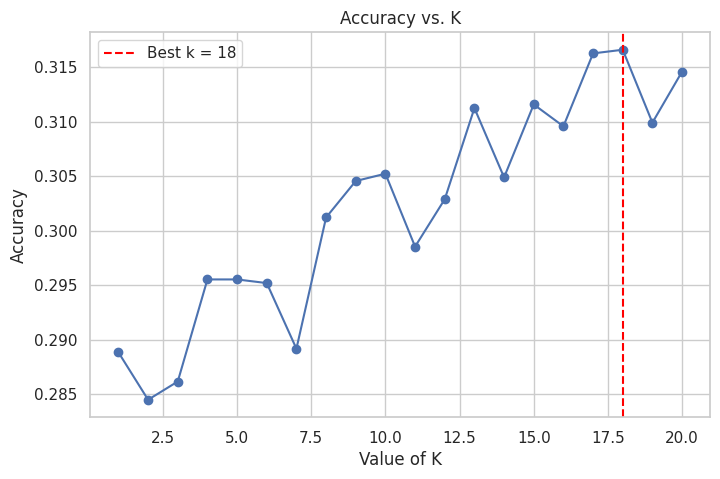

In [13]:
k_values = list(range(1, 21))
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, preds))

best_k = k_values[int(np.argmax(accuracy_scores))]
print(f"Best k: {best_k}, Best test accuracy: {max(accuracy_scores):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_scores, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k = {best_k}")
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. K")
plt.legend()
plt.show()

Accuracy: 0.3166
Precision: 0.3244
Recall: 0.3166
F1 Score: 0.3140

Confusion Matrix:
 [[123  69  13   2  31  77  62]
 [122  90  26  20  22  67  70]
 [ 39  33 223 118  23  29  23]
 [ 12   4 105 301  47   4   4]
 [ 99  71  15 112  77  58  56]
 [108  86   5  15  45  63  54]
 [116  79   2   0  32  67  69]]


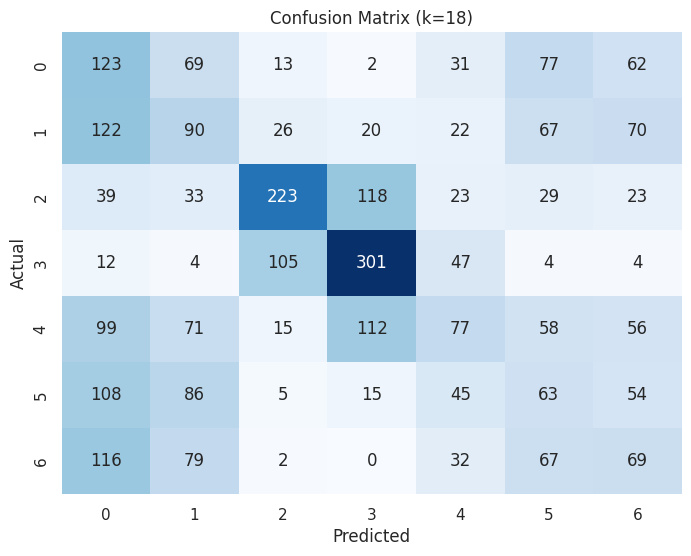

In [14]:
# Retrain with the best k and re-evaluate
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

evaluate_model(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (k={best_k})")
plt.show()

**Insight:** Tuning `k` gives a modest improvement over the default `k=5`, but accuracy stays well under 50% — the fundamental issue is **class imbalance and class overlap** (adjacent quality scores like 5 vs 6 are hard to separate), not just the choice of `k`.

## 8. Summary

- 14,940 clean records after removing 6,060 duplicates; no missing values.
- Target `quality` is a **7-class, imbalanced** ordinal variable — most wines score 5–6, very few score 3 or 9.
- Features were standardized since KNN is distance-based.
- Baseline KNN (`k=5`) test accuracy is low (~0.30); tuning `k` helps slightly but doesn't fix the core issue.
- **Next steps to improve:** treat `quality` as ordinal or bucket it into fewer classes (e.g. low/medium/high), address class imbalance (e.g. SMOTE, class weighting), or try a model less sensitive to imbalance (Random Forest, Gradient Boosting).